In [1]:
import pandas as pd
data = pd.read_csv("data/Walmart_Sales.csv")
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Data Exploration

In [2]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Interpreting Data Description
The results show 8 numbers for each column in your original dataset. The first number, the count, shows how many rows have non-missing values.

The second value is the mean, which is the average. Under that, std is the standard deviation, which measures how numerically spread out the values are.

For the min, 25%, 50%, 75% and max values, they sort the columns from the lowest to the highest value. The first (smallest) value is the min. If you go a quarter way through the list, you'll find a number that is bigger than 25% of the values and smaller than 75% of the values. That is the 25% value (pronounced "25th percentile"). The 50th and 75th percentiles are defined analogously, and the max is the largest number.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


As we can see, we have 5 columns with float values, 2 with integer values and 1 with character value which is the date (str)

We will start by seperating the date into 3 different columns; day, month and year

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

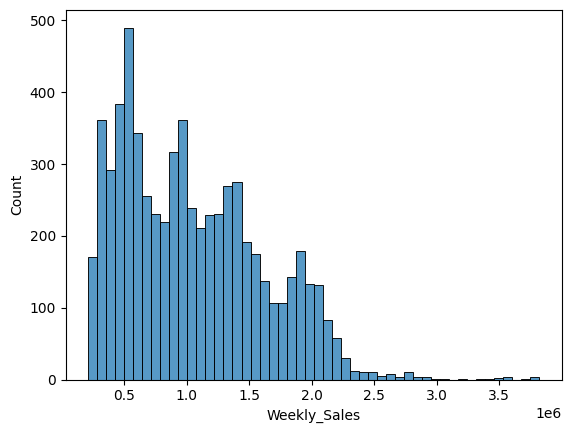

In [12]:
import seaborn as sns
sns.histplot(data['Weekly_Sales'], bins=50)

<Axes: xlabel='Weekly_Sales'>

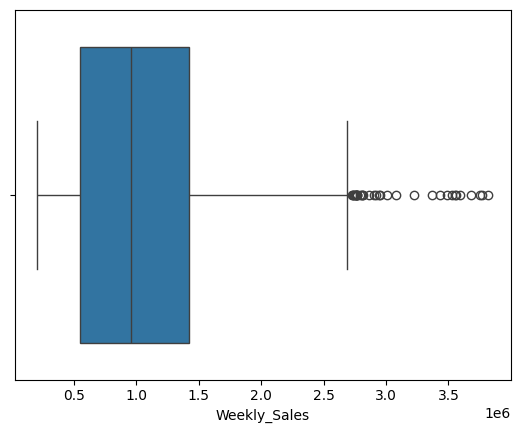

In [13]:
sns.boxplot(x=data['Weekly_Sales'])

The distribution of weekly sales is positively skewed, indicating that most weeks generate moderate revenue while a small number of weeks produce exceptionally high sales. The boxplot reveals several high-value outliers likely corresponding to holiday periods or promotional events. These observations suggest that seasonality and special events significantly influence sales patterns.

In [20]:
df = data.copy()

In [21]:
 df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

<Axes: xlabel='Date'>

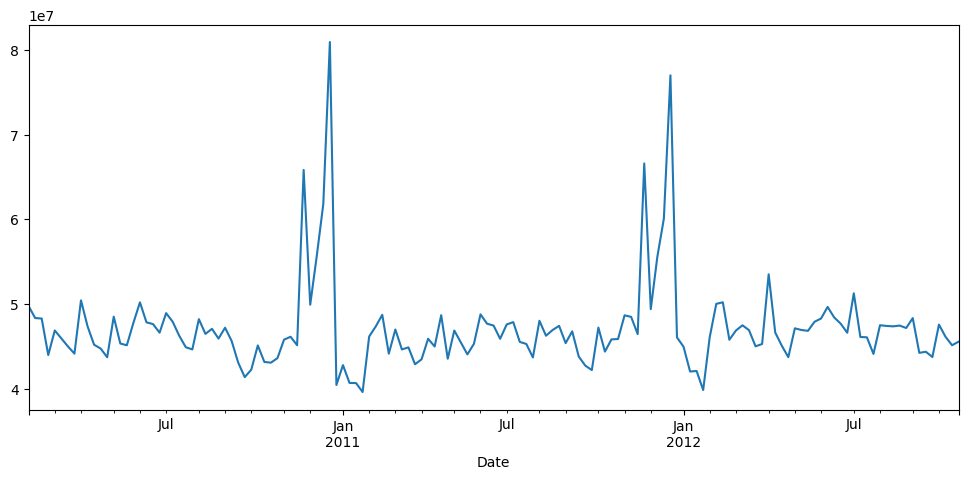

In [23]:
sales_over_time = df.groupby('Date')['Weekly_Sales'].sum()
sales_over_time.plot(figsize=(12,5))

The baseline remains relatively stable throughout the entire period, with minor fluctuations reflecting normal week-to-week variation in consumer behavior.
Two dominant spikes stand out clearly, occurring at roughly the same point each year — almost certainly corresponding to the Christmas/New Year holiday period, confirming strong and repeatable annual seasonality.
Smaller secondary spikes are also visible mid-year, likely tied to other recognized holiday events in the Walmart calendar.
Post-spike drops are equally sharp — sales fall notably right after each peak before gradually recovering to the baseline, the classic post-holiday correction.
No significant upward or downward trend is visible across the full period — the series is essentially stationary in its baseline, meaning what drives variation here is seasonality, not long-term growth.

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

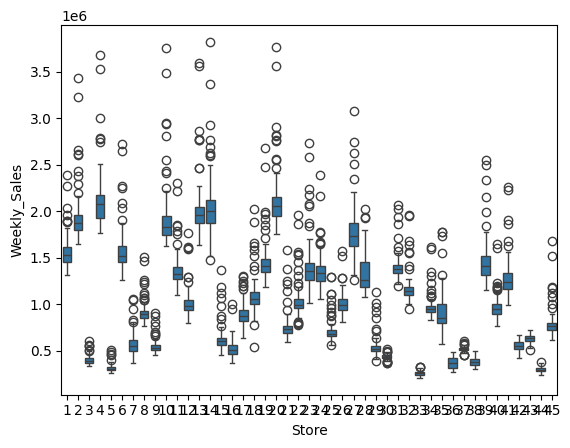

In [15]:
sns.boxplot(x='Store', y='Weekly_Sales', data=data)

The per-store boxplot reveals substantial heterogeneity across the 45 stores, with median weekly sales ranging from under 500K in some stores to over 2M in others. This wide disparity strongly suggests that stores differ in size, location, or customer base, and likely fall into distinct performance tiers. The varying box heights also indicate that some stores exhibit highly volatile sales while others remain relatively stable week to week. This confirms that Store identity will be a critical predictor in any predictive model.

<Axes: >

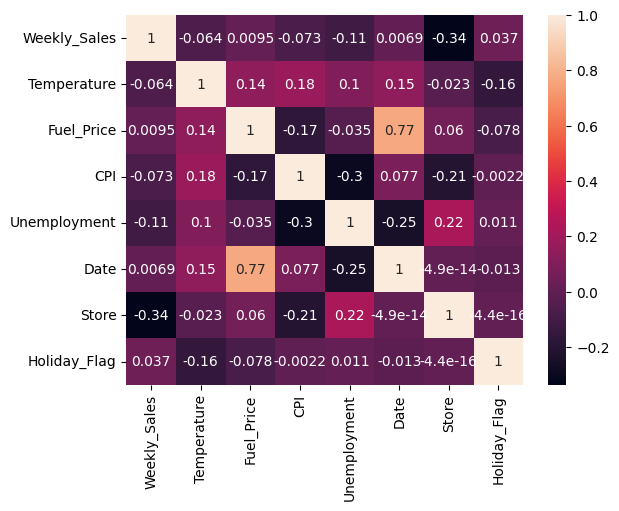

In [29]:
corr = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Date','Store', 'Holiday_Flag']].corr()
sns.heatmap(corr, annot=True)

Store has the strongest correlation with Weekly_Sales among all features, and it's negative; meaning as store number increases, sales tend to decrease.

Fuel_Price and Date have a very strong positive correlation. It means fuel prices rose consistently over time across the data collection period.

In [24]:
from modeling import todate
data1 = todate(data)

In [6]:
data1.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9
